# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Utils

In [4]:
def displayImage(img):
    # If image has 2 dimensions → grayscale
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    # If image has 3 dimensions → color
    elif len(img.shape) == 3:
        # Convert from OpenCV BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)

    plt.show()

def displayListOfImagesHorizontally(img_list):
    num_images = len(img_list)
    # Create 1 row, N columns
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*3, 3))  # adjust width per image

    # Ensure axes is always a list
    if num_images == 1:
        axes = [axes]

    for ax, img in zip(axes, img_list):
        # If image has 2 dimensions → grayscale
        if len(img.shape) == 2:
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        # If image has 3 dimensions → color
        elif len(img.shape) == 3:
            # Convert from OpenCV BGR to RGB
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
    
    plt.tight_layout()
    plt.show()

def displayHistogramOfBinaryImage(bin_img):
    # Sum white pixels along the vertical axis (axis=0)
    hist = np.sum(bin_img, axis=0)
    
    # Plot the histogram
    plt.figure(figsize=(12,4))
    plt.bar(range(bin_img.shape[1]), hist, color='black')
    plt.xlabel('X axis (columns)')
    plt.ylabel('Number of white pixels')
    plt.title('Vertical Histogram of White Pixels')
    plt.show()

# Load the Data

In [7]:
#Path to the data directory
data_dir = Path("../train/")

#Get list of all the Images
# glob searches for files matching a specific pattern in a directory (gives list of strings of file names)
images = sorted(list(map(str, list(data_dir.glob("*.png"))))) 
labels = [img.split(os.path.sep) [-1].split(".png")[0].split("-")[0] for img in images] # Get labels from file name
characters = set(char for label in labels for char in label) # Get set of all unique characters in labels

print("Number of images found: ", len(images))
print("Number of labels found:", len(labels))
print("Number of unique characters: ", len(characters))
print("Characters present: ", characters)

Number of images found:  8010
Number of labels found: 8010
Number of unique characters:  36
Characters present:  {'x', 'm', 'a', 'n', 'o', '0', 'k', '9', 'e', 'j', '7', 'c', 'l', '4', 't', 'i', 'y', 'p', '6', 'q', 'g', 'w', 'h', 's', 'f', 'b', '8', 'r', '5', '3', '1', 'v', 'z', 'u', '2', 'd'}


# Parameters

In [10]:
# Batch size for training and validation
# Smaller batch size requires less memory (good for GPUs with limited RAM) + adds some stochasticity, which can help escape local minima
batch_size = 16 

# Desired image dimensions
img_width = 550
img_height = 80

#Factor by which the image is going to be downsampled
#by the convolutional blocks. We will be using two
#convolution blocks and each block will have
#a pooling layer which downsample the features by a factor of 2.
#Hence total downsampling factor would be 4.
downsample_factor = 4

# Maximum length of any captcha in the dataset
max_length = max([len(label) for label in labels])

# Preprocessing the Dataset

### Character to Integer Mapping

In [14]:
# Mapping characters to integers
char_to_num = layers.StringLookup( # StringLookup is a layer in Keras that maps strings to integers
    vocabulary=list(characters), 
    # mask_token=None  # we are using 0 explicitly as blank
)

# Mapping integers back to original characters
num_to_char = layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(),  # ensure same order and indices
    invert=True, # This tells StringLookup to do the reverse mapping: integers → strings
    # mask_token=None  # we are using 0 explicitly as blank
)

sample = "abc"
encoded = char_to_num(tf.strings.unicode_split(sample, "UTF-8"))
decoded = tf.strings.reduce_join(num_to_char(encoded))
print(encoded.numpy(), decoded.numpy().decode("utf-8"))

[ 3 26 12] abc


### Split Data into Train and Validation Sets

In [17]:
def split_data(images, labels, train_size=0.9, shuffle=True):
    #1. Get the total size of the dataset
    size = len(images)
    #2. Make an indices array and shuffle it, if required
    indices = np.arange(size) # NumPy function that generates an array of numbers in a given range (here is incrementing by 1)
    if shuffle:
        np.random.shuffle(indices)
    #3. Get the size of training samples
    train_samples = int(size * train_size)
    #4. Split data into training and validation sets
    x_train, y_train = images[indices[:train_samples]], labels[indices[:train_samples]]
    x_valid, y_valid = images[indices[train_samples:]], labels[indices[train_samples:]] 
    return x_train, x_valid, y_train, y_valid

# Split the data
x_train, x_valid, y_train, y_valid = split_data(np.array(images), np.array(labels))

### Create Dataset Objects

In [20]:
def encode_single_sample(img_path, label):
    #1. Read image
    img = tf.io.read_file(img_path)
    #2. Decode and convert to grayscale
    img = tf.io.decode_png(img, channels=1)
    #3. Convert to float32 in [0, 1] range
    img = tf.image.convert_image_dtype(img, tf.float32)
    #4. Resize to the desired size
    img = tf.image.resize(img, [img_height, img_width])
    #5. Transpose the image because we want the time
    #dimension to correspond to the width of the image.
    img = tf.transpose(img, perm=[1, 0, 2])
    #6. Map the characters in label to numbers
    #tf.strings.unicode_split is a TensorFlow string operation that splits a string into individual Unicode characters.
    #char_to_num(...) converts each character to an integer index using StringLookup.
    label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8")) 
    #8. Return a dict as our model is expecting two inputs
    return {"image": img, "label": label}

In [24]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = (
    train_dataset.map(
        encode_single_sample, 
        num_parallel_calls=tf.data.experimental.AUTOTUNE # automatically choose the optimal number of parallel calls based on CPU cores and system load
    )
    .padded_batch( # groups consecutive elements of a dataset into batches of size batch_size, also pads the output labels to the same length
        batch_size,
        padded_shapes={
            "image": [img_width, img_height, 1],  # match the transposed shape exactly
            "label": [None]               # variable-length label
        },
        padding_values={
            "image": 0.0,
            "label": tf.constant(len(char_to_num.get_vocabulary()), dtype=tf.int64)  # use 0 as padding token
        }
    ) 
    .prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
)

validation_dataset = tf.data.Dataset.from_tensor_slices((x_valid, y_valid))
validation_dataset = (
    validation_dataset.map(
        encode_single_sample, num_parallel_calls=tf.data.experimental.AUTOTUNE
    )
    .padded_batch(
        batch_size,
        padded_shapes={
            "image": [img_width, img_height, 1],  
            "label": [None]               
        },
        padding_values={
            "image": 0.0,
            "label": tf.constant(len(char_to_num.get_vocabulary()), dtype=tf.int64) # use 0 as padding token
        }
    ) 
    .prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
)

### Visualize the Data

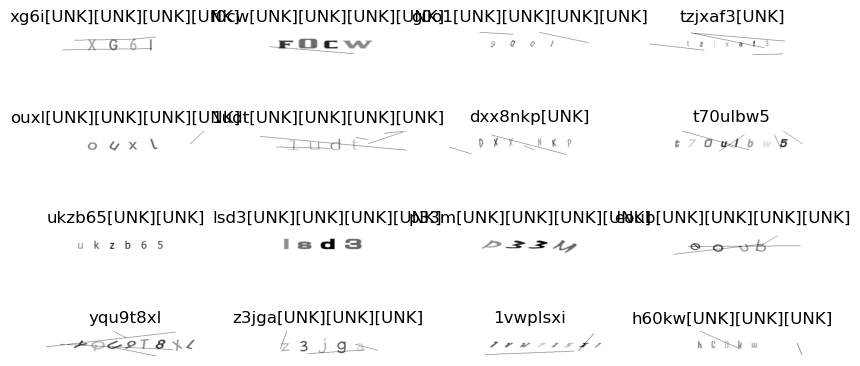

In [29]:
_, ax = plt.subplots (4, 4, figsize=(10, 5))
for batch in train_dataset.take(1): # creates a new dataset containing only the first 1 element (batch) of train_dataset.
    images = batch["image"] 
    labels = batch["label"]
    
    for i in range(16):
        img = (images[i] * 255).numpy().astype("uint8")
        label = tf.strings.reduce_join(num_to_char(labels[i])).numpy().decode("utf-8")
        ax[i // 4, i % 4].imshow(img[:, :, 0].T, cmap="gray")
        ax[i // 4, i % 4].set_title(label)
        ax[i // 4, i % 4].axis("off")
        
plt.show()

# Create the OCR Model

### Custom CTCLayer

With CTC Loss Function   
CTC is used for sequence prediction problems where
- Input sequences (e.g., images, audio) and output sequences (e.g., text) are different lengths.
- Alignment between input and output is unknown

The model outputs probabilities for each possible label at each time step, including a special blank symbol.  
CTC considers all possible alignments of the input to the target sequence.  
Loss is the negative log probability of all valid alignments that can produce the target sequence.  

In [33]:
# Custom Keras layer that wraps the CTC loss function so that it can be integrated directly into your model
class CTCLayer(layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name) 
        self.loss_fn = keras.backend.ctc_batch_cost # stores the CTC loss function for use in call
    
    def call(self, y_true, y_pred):
        # Compute the training-time loss value and add it
        # to the layer using 'self.add_loss()".

        # y_true → padded labels, shape [batch_size, max_label_len]
        # y_pred → model predictions, shape [batch_size, time_steps, num_classes]
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64") # length of the input sequence (time steps)
        label_length = tf.cast(tf.shape(y_true)[1], dtype="int64") # length of the true label sequence

        # Since all sequences in this implementation are the same length, we create tensors filled with that length.
        input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        
        loss = self.loss_fn(y_true, y_pred, input_length, label_length) # keras.backend.ctc_batch_cost computes the CTC loss for the whole batch
        self.add_loss(loss) # add_loss() tells Keras that this loss should be included in total model loss during training.
        
        #At test time, just return the computed predictions
        return y_pred

### Build the Model

In [36]:
def build_model():
    #Inputs to the model
    input_img = layers.Input(
        shape=(img_width, img_height, 1), # specify input image shape
        name="image", 
        dtype="float32"
    )
    labels = layers.Input( # specify input for labels
        name="label",
        shape=(None,), 
        dtype="float32"
    )
    
    #First conv block
    x = layers.Conv2D(
        32, # 32 kernels
        (3, 3), # 3x3 kernel
        activation = "relu",
        kernel_initializer="he_normal", # Initializes the weights using He Normal initialization (good for ReLU activations).
        padding="same", # Ensures the output has the same spatial dimensions (height & width) as the input. (pad with 0 if needed)
        name="Conv1", # Assigns a name to the layer for easier reference in the model.
    )(input_img)
    x = layers.MaxPooling2D(
        (2, 2), # Takes a 2×2 window and keeps only the maximum value in that window.
        name="pool1")(x)

    #Second conv block
    x = layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same",
        name="Conv2",
    )(x)
    x = layers.MaxPooling2D((2, 2), name="poo12")(x)

    #We have used two max pool with pool size and strides 2.
    #Hence, downsampled feature maps are 4x smaller. The number of
    #filters in the last layer is 64. Reshape accordingly before
    #passing the output to the RNN part of the model
    new_shape = ((img_width // 4), (img_height // 4) * 64)
    x = layers.Reshape(target_shape=new_shape, name="reshape")(x)
    x = layers.Dense(64, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.2)(x) 

    #RNNS
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25))(x)
    
    #Output layer
    x = layers.Dense(len(char_to_num.get_vocabulary()) + 1, activation="softmax", name="dense2")(x)
    
    # Add our custom CTC layer for calculating CTC loss at each step
    output = CTCLayer(name="ctc_loss")(labels, x)

    #Define the model
    model = keras.models.Model(
        inputs=[input_img, labels], outputs=output, name="ocr_model_v1"
    )
    # Optimizer
    opt = keras.optimizers.Adam()
    #Compile the model and return
    model.compile(optimizer=opt)
    return model

# Get the model
model = build_model()
model.summary()

Model: "ocr_model_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)            │ (None, 550, 80, 1)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 550, 80, 32)       │             320 │ image[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 275, 40, 32)       │               0 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv2 (Conv2D)                │ (None, 275, 40, 64)       │          18,496 │ pool1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ poo12 (MaxPooling2D)          │ (None, 137, 20, 64)       │               0 │ Conv2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 137, 1280)         │               0 │ poo12[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense1 (Dense)                │ (None, 137, 64)           │          81,984 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 137, 64)           │               0 │ dense1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 137, 256)          │         197,632 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 137, 128)          │         164,352 │ bidirectional[0][0]        │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ label (InputLayer)            │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense2 (Dense)                │ (None, 137, 38)           │           4,902 │ bidirectional_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ctc_loss (CTCLayer)           │ (None, 137, 38)           │               0 │ label[0][0], dense2[0][0]  │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 467,686 (1.78 MB)

 Trainable params: 467,686 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

# Train the Model
with model.fit

In [39]:
epochs = 10
early_stopping_patience = 10 # If our model hasn't improved for 10 epochs, terminate and restore best model params
# Add early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", # Watches the loss on the validation dataset after each epoch (for "improvement")
    patience=early_stopping_patience, 
    restore_best_weights=True
)

# Train the model
# History tores loss and metrics for each epoch.
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping], # A list of callbacks that perform actions at certain points during training (here is early stopping)
)

Epoch 1/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 163s 338ms/step - loss: 427.4918 - val_loss: 371.7408
Epoch 2/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 197s 327ms/step - loss: 376.4858 - val_loss: 371.7009
Epoch 3/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 201s 325ms/step - loss: 376.3402 - val_loss: 371.5756
Epoch 4/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 150s 332ms/step - loss: 376.0845 - val_loss: 371.3976
Epoch 5/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 147s 326ms/step - loss: 375.7271 - val_loss: 370.9630
Epoch 6/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 150s 332ms/step - loss: 374.4980 - val_loss: 369.8204
Epoch 7/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 156s 346ms/step - loss: 372.2816 - val_loss: 369.1748
Epoch 8/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 149s 330ms/step - loss: 370.5503 - val_loss: 365.7392
Epoch 9/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 152s 337ms/step - loss: 369.4854 - val_loss: 365.1702
Epoch 10/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 147s 326ms/step - loss: 368.7998 - val_loss: 364.7578


### Plot Training Result

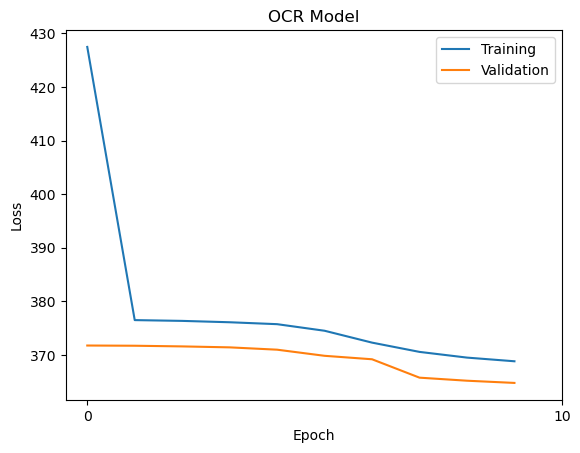

In [42]:
# Plot the loss of the model during training
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xticks(range(0, epochs+1,10))
plt.title("OCR Model")
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

# Predictions with the model
Tutorial: https://www.youtube.com/watch?v=BWgSSgTdaMk

In [74]:
# Get the prediction model by extracting layers till the output layer
# This creates a new Keras model that shares the same layers and weights as your trained model,
# but only includes part of it — from the image input layer up to the layer named dense2 (our output layer).
# Because we dont need the CTC loss or training parts anymore.
prediction_model = keras.models.Model(
    model.get_layer(name="image").output, 
    model.get_layer(name="dense2").output
)
prediction_model.summary()

#A utility function to decode the output of the network
def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    # Use greedy search. For complex tasks, you can use beam search
    results = keras.backend.ctc_decode(pred, input_length=input_len, greedy=True) [0][0][
        :, :max_length
    ]
    
    #Iterate over each digit and get back the character
    output_text = []
    for res in results:
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    
    return output_text

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 550, 80, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1 (Conv2D)                       │ (None, 550, 80, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 275, 40, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 275, 40, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ poo12 (MaxPooling2D)                 │ (None, 137, 20, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 137, 1280)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 137, 64)             │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 137, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 137, 256)            │         197,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 137, 128)            │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense2 (Dense)                       │ (None, 137, 38)             │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 467,686 (1.78 MB)

 Trainable params: 467,686 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

### Let's check results on some validation samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
[[[2.15531815e-10 1.75611476e-05 1.22950532e-05 ... 1.96594756e-05
   1.09043094e-05 9.99152541e-01]
  [5.91328375e-12 6.26995688e-06 3.81980135e-06 ... 7.65845652e-06
   4.41953807e-06 9.99695897e-01]
  [2.42463688e-12 4.78025959e-06 2.95972723e-06 ... 6.30478735e-06
   3.79987569e-06 9.99760568e-01]
  ...
  [1.25397666e-04 2.14912500e-02 1.52587956e-02 ... 2.27785092e-02
   1.88383870e-02 2.15364248e-01]
  [1.96603214e-04 2.44884733e-02 1.68517940e-02 ... 2.50654463e-02
   2.08024830e-02 1.58040822e-01]
  [2.68660224e-04 2.66162287e-02 1.82325561e-02 ... 2.61537861e-02
   2.23280080e-02 1.25675231e-01]]

 [[3.01844827e-10 1.91225554e-05 1.38427649e-05 ... 2.15308228e-05
   1.21813891e-05 9.99062121e-01]
  [8.68254427e-12 6.96985808e-06 4.43901035e-06 ... 8.48044328e-06
   5.04794480e-06 9.99657631e-01]
  [3.57226922e-12 5.36686866e-06 3.51724566e-06 ... 7.05818275e-06
   4.43456111e-06 9.99727666e-01]
  ...
  [1.59616742e-04 2.45704036e-02 2.607

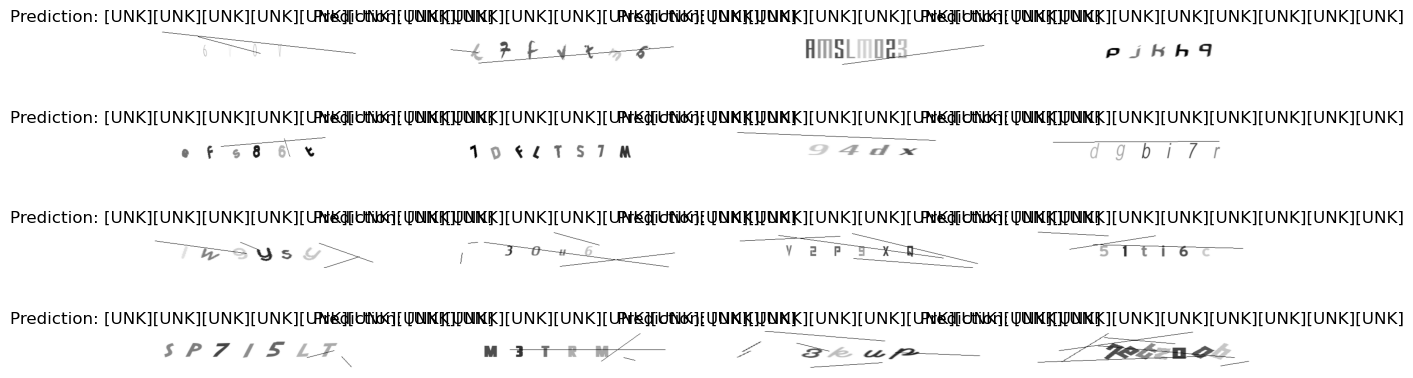

In [81]:
#Let's check results on some validation samples
for batch in validation_dataset.take(1):
    batch_images = batch["image"]
    batch_labels = batch["label"]
    
    preds = prediction_model.predict(batch_images)
    pred_texts = decode_batch_predictions(preds)

    print(preds)

    orig_texts = []
    for label in batch_labels:
        label = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
        orig_texts.append(label)

    _, ax = plt.subplots (4, 4, figsize=(15, 5))
    for i in range(len(pred_texts)):
        img = (batch_images[i, :, :, 0] * 255).numpy().astype(np.uint8)
        img = img.T
        title = f"Prediction: {pred_texts[i]}"
        ax[i // 4, i % 4].imshow(img, cmap="gray")
        ax[i // 4, i % 4].set_title(title)
        ax[i // 4, i % 4].axis("off")
        
plt.show()